In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset,DataLoader
from torchvision import transforms

from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from Crypto.Util import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from Crypto.Random import get_random_bytes

device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


cuda
NVIDIA GeForce RTX 3050 Laptop GPU


In [8]:
DATASET_PATH=r"C:\Users\Yashraj Singh\OneDrive\Desktop\archive\seg_train\seg_train"

IMAGE_SIZE=150

BATCH_SIZE=64

EPOCHS=20

LEARNING_RATE=0.0001

AES_KEY=b"ThisIsA16ByteKey"
FIXED_IV=b"1234567890ABCDEF"

FIXED_NONCE=b"12345678"

In [9]:
image_paths=[]

for root,dirs,files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".jpg"):

            image_paths.append(
                os.path.join(
                    root,
                    file
                )
            )

print("Images =",len(image_paths))

Images = 14034


In [10]:
print("Using Images =",len(image_paths))

Using Images = 14034


In [11]:
def encrypt_cbc(image_array):

    image_bytes=image_array.tobytes()

    iv=FIXED_IV

    cipher=AES.new(
        AES_KEY,
        AES.MODE_CBC,
        iv=iv
    )

    encrypted=cipher.encrypt(
        pad(image_bytes,AES.block_size)
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted


def encrypt_ctr(image_array):

    image_bytes=image_array.tobytes()

    nonce=FIXED_NONCE

    cipher=AES.new(
        AES_KEY,
        AES.MODE_CTR,
        nonce=nonce
    )

    encrypted=cipher.encrypt(
        image_bytes
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted


def encrypt_cfb(image_array):

    image_bytes=image_array.tobytes()

    iv=FIXED_IV

    cipher=AES.new(
        AES_KEY,
        AES.MODE_CFB,
        iv=iv
    )

    encrypted=cipher.encrypt(
        image_bytes
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted


def encrypt_ofb(image_array):

    image_bytes=image_array.tobytes()

    iv=FIXED_IV

    cipher=AES.new(
        AES_KEY,
        AES.MODE_OFB,
        iv=iv
    )

    encrypted=cipher.encrypt(
        image_bytes
    )

    encrypted=np.frombuffer(
        encrypted[:image_array.size],
        dtype=np.uint8
    )

    encrypted=encrypted.reshape(
        image_array.shape
    )

    return encrypted

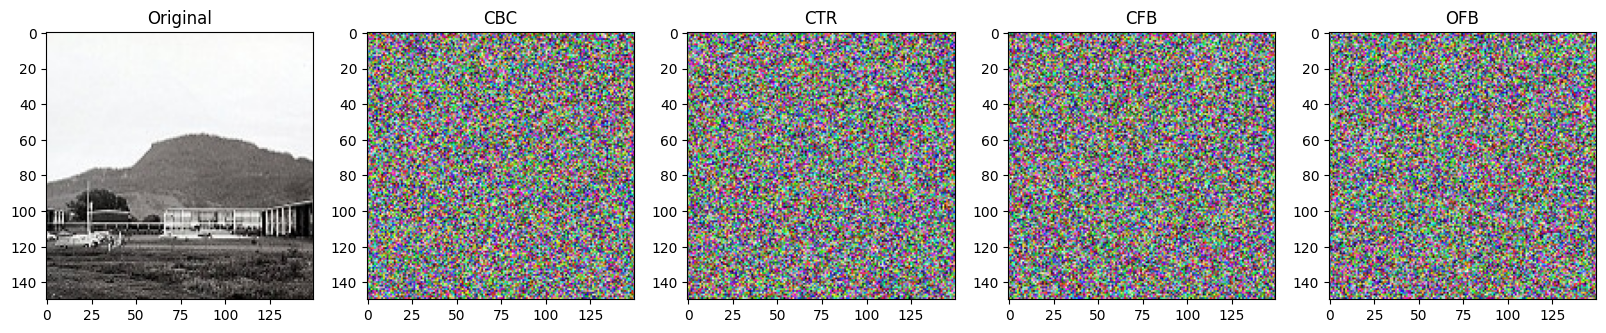

In [12]:
img=np.array(
    Image.open(
        image_paths[0]
    ).resize(
        (IMAGE_SIZE,IMAGE_SIZE)
    )
)

cbc=encrypt_cbc(img)

ctr=encrypt_ctr(img)

cfb=encrypt_cfb(img)

ofb=encrypt_ofb(img)

plt.figure(figsize=(20,5))

plt.subplot(1,5,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,5,2)
plt.imshow(cbc)
plt.title("CBC")

plt.subplot(1,5,3)
plt.imshow(ctr)
plt.title("CTR")

plt.subplot(1,5,4)
plt.imshow(cfb)
plt.title("CFB")

plt.subplot(1,5,5)
plt.imshow(ofb)
plt.title("OFB")

plt.show()

In [13]:
train_paths,val_paths=train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

print(len(train_paths))
print(len(val_paths))

11227
2807


In [14]:
class AESDataset(Dataset):

    def __init__(
        self,
        image_paths
    ):

        self.image_paths=image_paths

        self.transform=transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10)
        ])

    def __len__(self):

        return len(self.image_paths)*4

    def __getitem__(self,index):

        image_index=index//4

        class_label=index%4

        path=self.image_paths[
            image_index
        ]

        img=Image.open(path)

        img=img.convert("RGB")

        img=img.resize(
            (
                IMAGE_SIZE,
                IMAGE_SIZE
            )
        )

        img=self.transform(img)

        img=np.array(img)

        if class_label==0:

            img=encrypt_cbc(img)

        elif class_label==1:

            img=encrypt_ctr(img)

        elif class_label==2:

            img=encrypt_cfb(img)

        else:

            img=encrypt_ofb(img)

        img=img.astype(np.float32)

        img=img/255.0

        img=torch.tensor(
            img,
            dtype=torch.float32
        )

        img=img.permute(
            2,
            0,
            1
        )

        return img,class_label

In [15]:
train_dataset=AESDataset(
    train_paths
)

val_dataset=AESDataset(
    val_paths
)

print(len(train_dataset))
print(len(val_dataset))

44908
11228


In [16]:
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader=DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders Created")

DataLoaders Created


In [17]:
images,labels=next(
    iter(train_loader)
)

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 150, 150])
torch.Size([64])


In [18]:
class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features=nn.Sequential(

            nn.Conv2d(
                3,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                128,
                256,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier=nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256*9*9,
                512
            ),

            nn.ReLU(),

            nn.Linear(
                512,
                4
            )
        )

    def forward(self,x):

        x=self.features(x)

        x=self.classifier(x)

        return x

In [19]:
model=CNN().to(device)

criterion=nn.CrossEntropyLoss()

optimizer=optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(
    next(
        model.parameters()
    ).device
)

cuda:0


In [20]:
train_losses=[]
val_losses=[]

print("Starting Training")

for epoch in range(EPOCHS):

    model.train()

    train_loss=0

    for images,labels in train_loader:

        images=images.to(device)

        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    train_losses.append(
        train_loss
    )

    model.eval()

    val_loss=0

    correct=0

    total=0

    with torch.no_grad():

        for images,labels in val_loader:

            images=images.to(device)

            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(
                outputs,
                labels
            )

            val_loss+=loss.item()

            _,predicted=torch.max(
                outputs,
                1
            )

            total+=labels.size(0)

            correct+=(
                predicted==labels
            ).sum().item()

    val_loss/=len(val_loader)

    val_losses.append(
        val_loss
    )

    accuracy=100*correct/total

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Train Loss:{train_loss:.4f} "
        f"Val Loss:{val_loss:.4f} "
        f"Val Accuracy:{accuracy:.2f}%"
    )

Starting Training
Epoch 1/20 Train Loss:0.6351 Val Loss:0.3697 Val Accuracy:74.81%
Epoch 2/20 Train Loss:0.3150 Val Loss:0.1360 Val Accuracy:94.84%
Epoch 3/20 Train Loss:0.1022 Val Loss:0.0837 Val Accuracy:96.61%
Epoch 4/20 Train Loss:0.0706 Val Loss:0.0703 Val Accuracy:97.19%
Epoch 5/20 Train Loss:0.0659 Val Loss:0.0638 Val Accuracy:97.41%
Epoch 6/20 Train Loss:0.0625 Val Loss:0.0572 Val Accuracy:97.69%
Epoch 7/20 Train Loss:0.0585 Val Loss:0.0553 Val Accuracy:97.78%
Epoch 8/20 Train Loss:0.0593 Val Loss:0.0580 Val Accuracy:97.93%
Epoch 9/20 Train Loss:0.0543 Val Loss:0.0479 Val Accuracy:98.12%
Epoch 10/20 Train Loss:0.0534 Val Loss:0.0580 Val Accuracy:97.48%
Epoch 11/20 Train Loss:0.0518 Val Loss:0.0442 Val Accuracy:98.25%
Epoch 12/20 Train Loss:0.0495 Val Loss:0.0466 Val Accuracy:98.15%
Epoch 13/20 Train Loss:0.0479 Val Loss:0.0458 Val Accuracy:98.10%
Epoch 14/20 Train Loss:0.0470 Val Loss:0.0478 Val Accuracy:98.19%
Epoch 15/20 Train Loss:0.0468 Val Loss:0.0473 Val Accuracy:98.10%
E

In [21]:
all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():

    for images,labels in val_loader:

        images=images.to(device)

        outputs=model(images)

        _,preds=torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

cm=confusion_matrix(
    all_labels,
    all_preds
)

print(cm)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "CBC",
            "CTR",
            "CFB",
            "OFB"
        ]
    )
)

[[2773    0   34    0]
 [   0 2807    0    0]
 [ 166    0 2641    0]
 [   1    0    0 2806]]
              precision    recall  f1-score   support

         CBC       0.94      0.99      0.97      2807
         CTR       1.00      1.00      1.00      2807
         CFB       0.99      0.94      0.96      2807
         OFB       1.00      1.00      1.00      2807

    accuracy                           0.98     11228
   macro avg       0.98      0.98      0.98     11228
weighted avg       0.98      0.98      0.98     11228



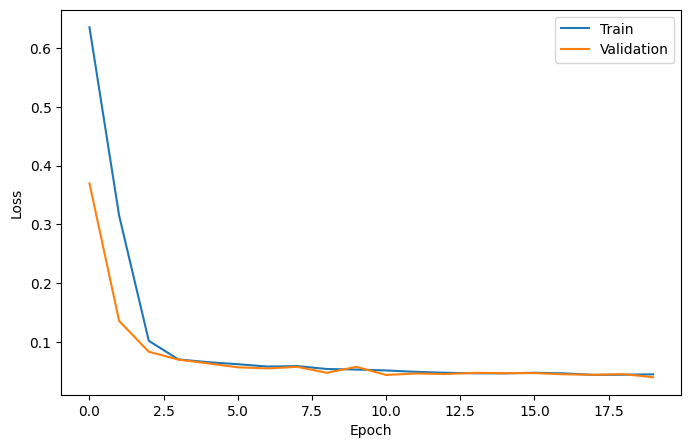

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [23]:
torch.save(
    model.state_dict(),
    "intel_aes_classifier.pth"
)